# E-Commerce Customer Churn Prediction

**Goal:** Build a complete churn prediction project using the dataset **E-Commerce Customer Churn Analysis and Prediction** .

Dataset: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction


## 1. Import Libraries

In [3]:
# Optional installs. Uncomment if needed.
!pip install pandas numpy matplotlib scikit-learn openpyxl xgboost shap

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)
print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [60]:
DATA_PATH = '/content/drive/MyDrive/Datasets/customer-churn/data/ecommerce-dataset.xlsx'

df = pd.read_excel(DATA_PATH, sheet_name='ecomm')
print('Dataset loaded successfully')

print('Shape:', df.shape)
df.head()

Dataset loaded successfully
Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [59]:
data_def = pd.read_excel(DATA_PATH, sheet_name='data-dict')
print(data_def)

      Data                     Variable  \
0   E Comm                   CustomerID   
1   E Comm                        Churn   
2   E Comm                       Tenure   
3   E Comm         PreferredLoginDevice   
4   E Comm                     CityTier   
5   E Comm              WarehouseToHome   
6   E Comm         PreferredPaymentMode   
7   E Comm                       Gender   
8   E Comm               HourSpendOnApp   
9   E Comm     NumberOfDeviceRegistered   
10  E Comm             PreferedOrderCat   
11  E Comm            SatisfactionScore   
12  E Comm                MaritalStatus   
13  E Comm              NumberOfAddress   
14  E Comm                     Complain   
15  E Comm  OrderAmountHikeFromlastYear   
16  E Comm                   CouponUsed   
17  E Comm                   OrderCount   
18  E Comm            DaySinceLastOrder   
19  E Comm               CashbackAmount   

                                          Discerption  
0                                  Uniqu

## 3. Basic Data Understanding

Questions to check:

- How many customers do we have?
- What columns describe customer behavior?
- What column tells us whether the customer churned?

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,NaN,NaN,NaN,52815.5,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5366.0,NaN,NaN,NaN,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,NaN,NaN,NaN,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5375.0,NaN,NaN,NaN,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


In [16]:
print('Columns:')
for col in df.columns:
    print('-', col)

Columns:
- CustomerID
- Churn
- Tenure
- PreferredLoginDevice
- CityTier
- WarehouseToHome
- PreferredPaymentMode
- Gender
- HourSpendOnApp
- NumberOfDeviceRegistered
- PreferedOrderCat
- SatisfactionScore
- MaritalStatus
- NumberOfAddress
- Complain
- OrderAmountHikeFromlastYear
- CouponUsed
- OrderCount
- DaySinceLastOrder
- CashbackAmount


## 4. Clean Column Names

We make column names easier to use in Python.

In [17]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.replace('/', '_')
)

print(df.columns.tolist())
df.head()

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 5. Check Target Variable

column `Churn` exists and means

- `1` = churned customer
- `0` = retained customer

In [61]:
TARGET = 'Churn'

print(df[TARGET].value_counts(dropna=False))
print('Churn rate:')
print(df[TARGET].mean())

Churn
0    4682
1     948
Name: count, dtype: int64
Churn rate:
0.16838365896980462


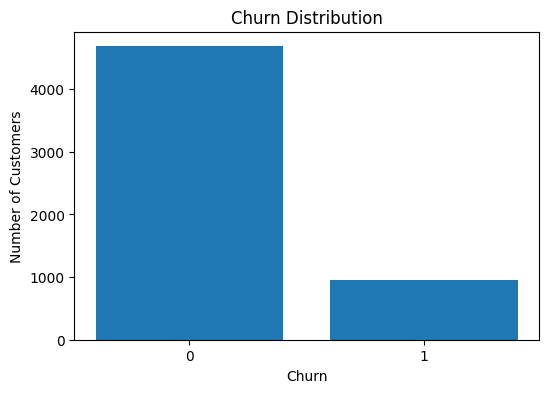

In [62]:
churn_counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## 6. Missing Value Analysis

Missing values are common in customer datasets. We first inspect them, then impute them later in the ML pipeline.

In [63]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0]

,missing_count,missing_pct
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


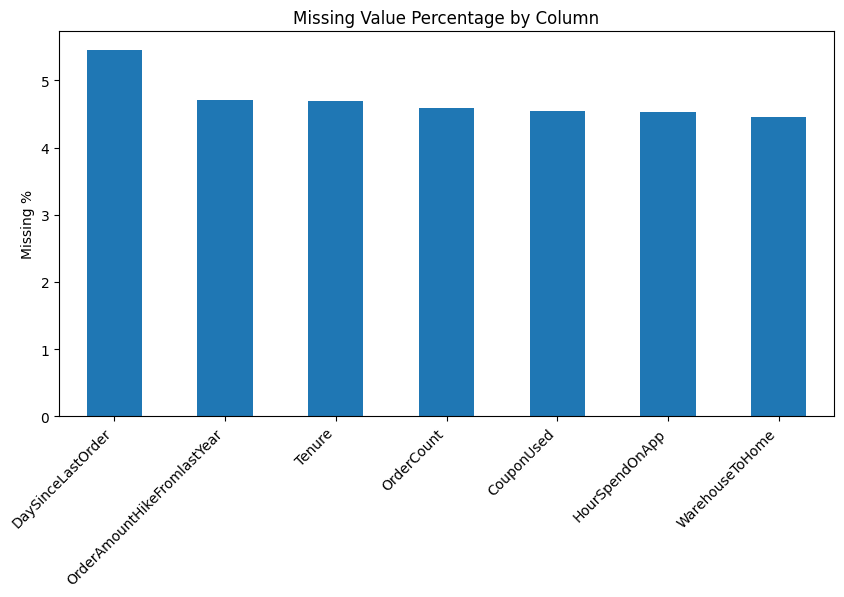

In [21]:
plt.figure(figsize=(10,5))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.title('Missing Value Percentage by Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. Duplicate Check

In [64]:
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)


Duplicate rows: 0


## 8. Separate Numerical and Categorical Columns

In [65]:
id_like_cols = [col for col in df.columns if col.lower() in ['customerid', 'customer_id', 'id']]

feature_cols = [col for col in df.columns if col != TARGET]
feature_cols = [col for col in feature_cols if col not in id_like_cols]

numeric_cols = df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('ID-like columns removed:', id_like_cols)
print('')
print('Numeric columns:', numeric_cols)
print('')
print('Categorical columns:', categorical_cols)

ID-like columns removed: ['CustomerID']

Numeric columns: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


## 9. EDA: Churn Rate by Categorical Features

This helps answer: **which customer groups churn more?**

Churn rate by PreferredLoginDevice


,churn_rate
PreferredLoginDevice,
Phone,0.224208
Computer,0.198286
Mobile Phone,0.125859


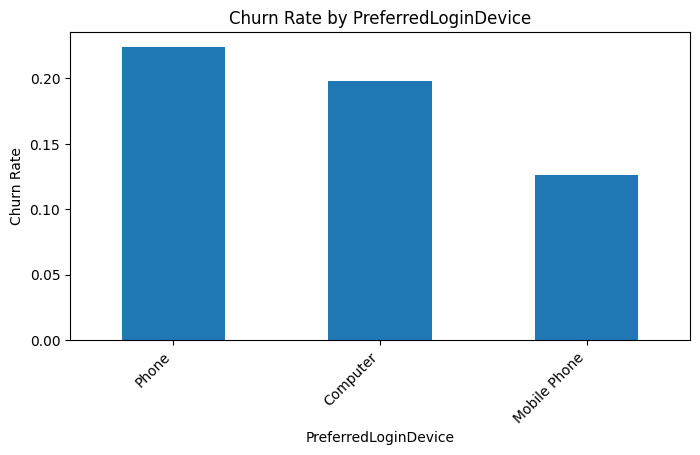

Churn rate by PreferredPaymentMode


,churn_rate
PreferredPaymentMode,
COD,0.287671
E wallet,0.228013
CC,0.216117
UPI,0.173913
Cash on Delivery,0.154362
Debit Card,0.153846
Credit Card,0.128581


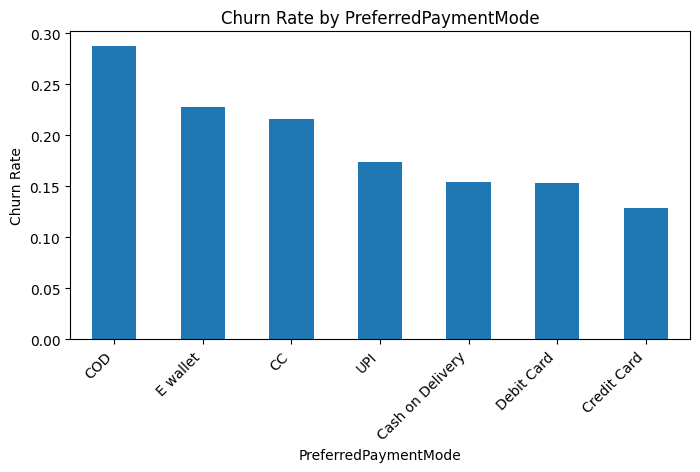

Churn rate by Gender


,churn_rate
Gender,
Male,0.177305
Female,0.154942


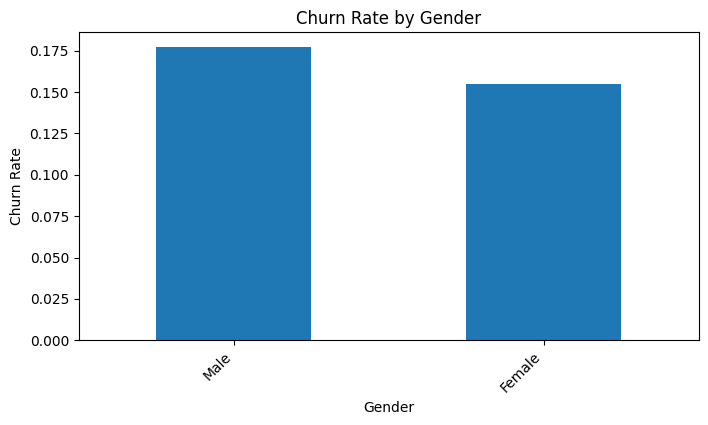

Churn rate by PreferedOrderCat


,churn_rate
PreferedOrderCat,
Mobile Phone,0.275374
Mobile,0.271941
Fashion,0.154964
Laptop & Accessory,0.102439
Others,0.075758
Grocery,0.048780


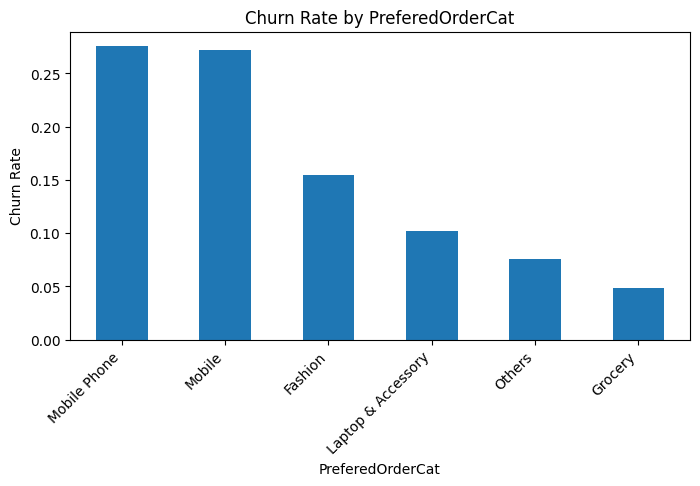

Churn rate by MaritalStatus


,churn_rate
MaritalStatus,
Single,0.267261
Divorced,0.146226
Married,0.115204


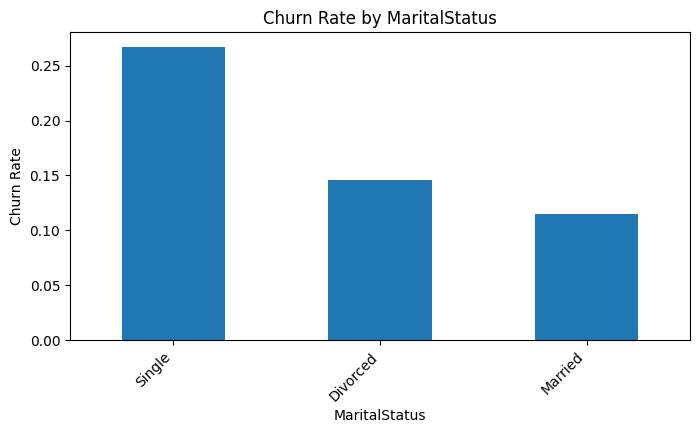

In [66]:
for col in categorical_cols:
    churn_by_group = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    print('' +'=' *60)
    print(f'Churn rate by {col}')
    display(churn_by_group.to_frame('churn_rate'))

    plt.figure(figsize=(8,4))
    churn_by_group.plot(kind='bar')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 10. EDA: Numerical Feature Distributions

Compare churned vs retained customers.

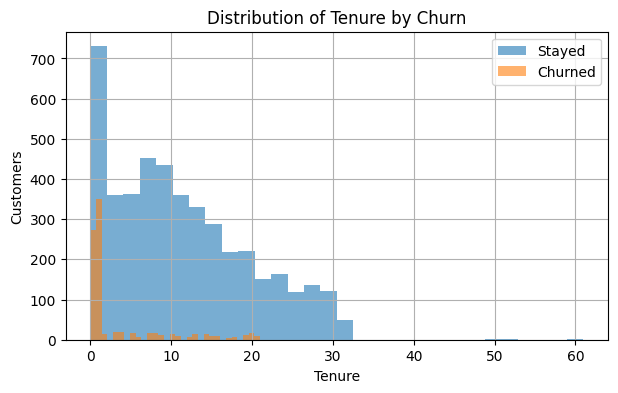

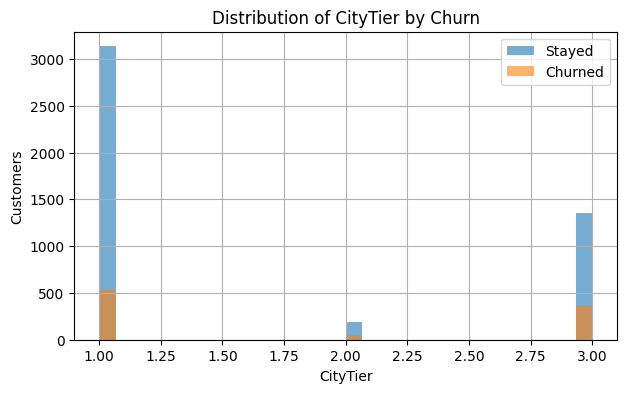

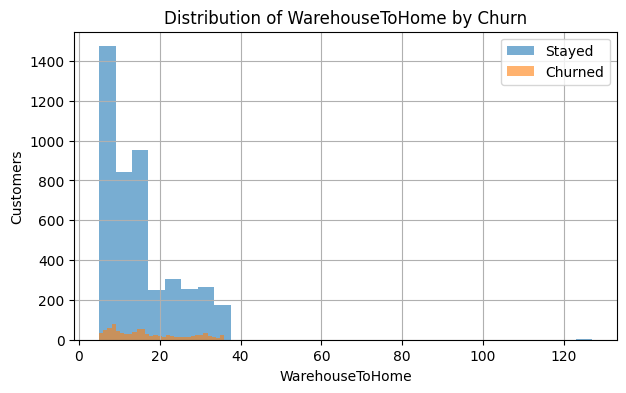

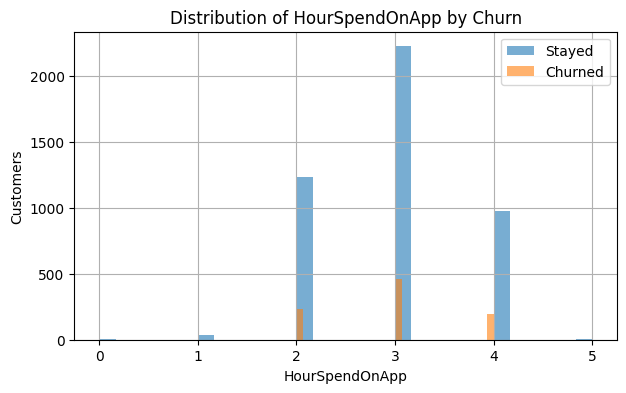

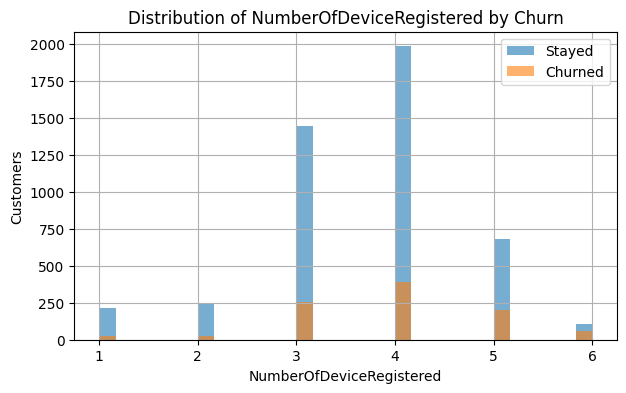

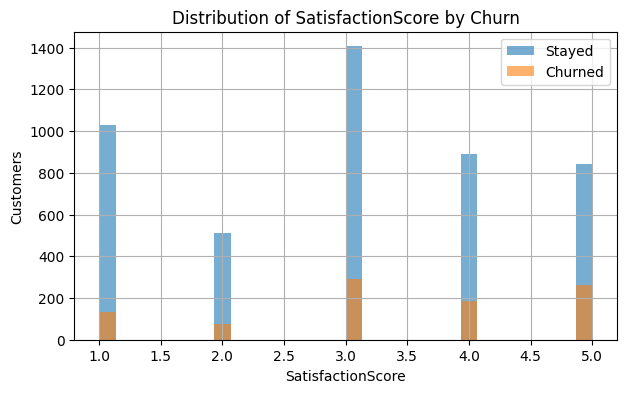

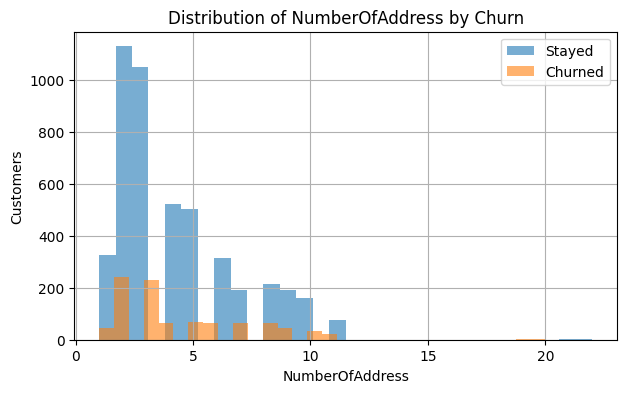

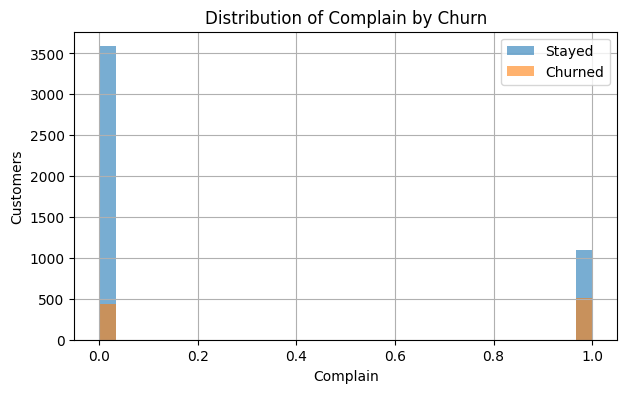

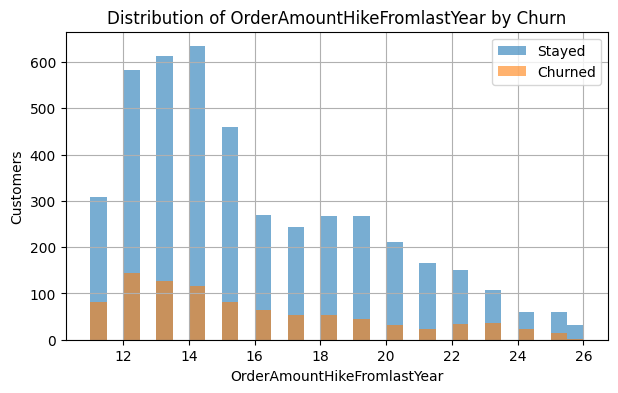

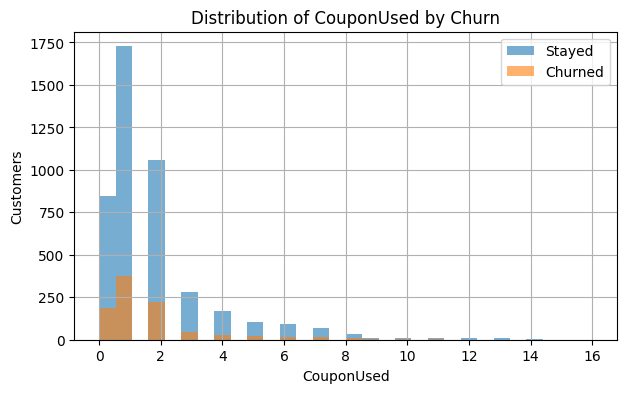

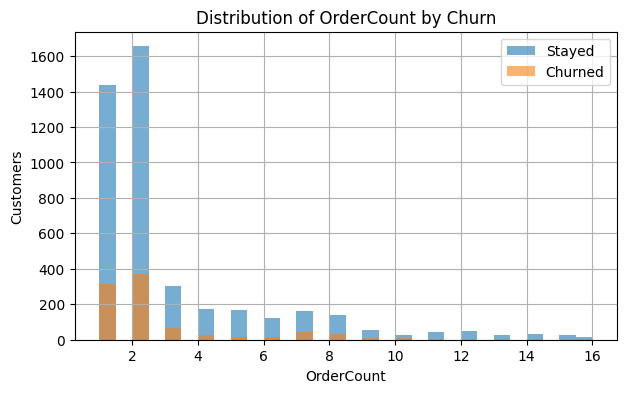

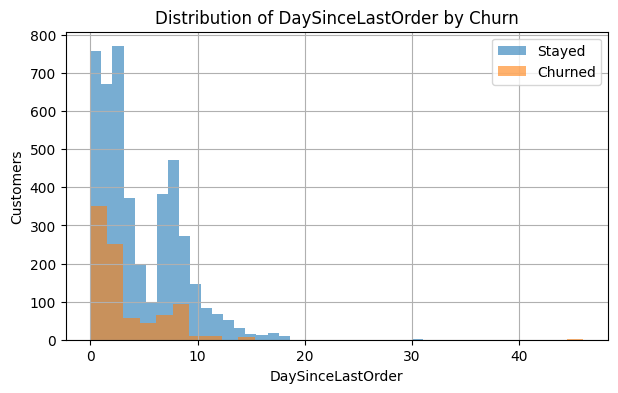

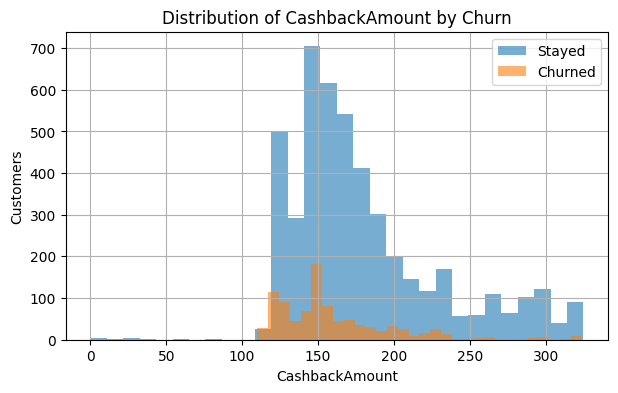

In [67]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    df[df[TARGET] == 0][col].dropna().hist(alpha=0.6, bins=30, label='Stayed')
    df[df[TARGET] == 1][col].dropna().hist(alpha=0.6, bins=30, label='Churned')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Customers')
    plt.legend()
    plt.show()

## 11. EDA: Average Numeric Features by Churn

This gives simple business-friendly insights.

In [31]:
numeric_summary = df.groupby(TARGET)[numeric_cols].mean().T
numeric_summary.columns = ['Stayed_0', 'Churned_1']
numeric_summary['difference_churned_minus_stayed'] = numeric_summary['Churned_1'] - numeric_summary['Stayed_0']
numeric_summary.sort_values('difference_churned_minus_stayed', ascending=False)

,Stayed_0,Churned_1,difference_churned_minus_stayed
WarehouseToHome,15.353931,17.134259,1.780328
SatisfactionScore,3.001282,3.390295,0.389014
NumberOfAddress,4.162965,4.466245,0.303280
Complain,0.234088,0.535865,0.301777
NumberOfDeviceRegistered,3.639257,3.934599,0.295342
CityTier,1.619821,1.827004,0.207184
HourSpendOnApp,2.925530,2.961798,0.036268
CouponUsed,1.758232,1.717021,-0.041211
OrderAmountHikeFromlastYear,15.724893,15.627409,-0.097484
OrderCount,3.046601,2.823656,-0.222945


## 12. Correlation Check

Correlation helps find numeric variables associated with churn.

Do not treat correlation as causation. It is only a signal.

In [32]:
corr = df[numeric_cols + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
corr

,Churn
Churn,1.000000
Complain,0.250188
NumberOfDeviceRegistered,0.107939
SatisfactionScore,0.105481
CityTier,0.084703
WarehouseToHome,0.076630
NumberOfAddress,0.043931
HourSpendOnApp,0.018675
CouponUsed,-0.008264
OrderAmountHikeFromlastYear,-0.010058


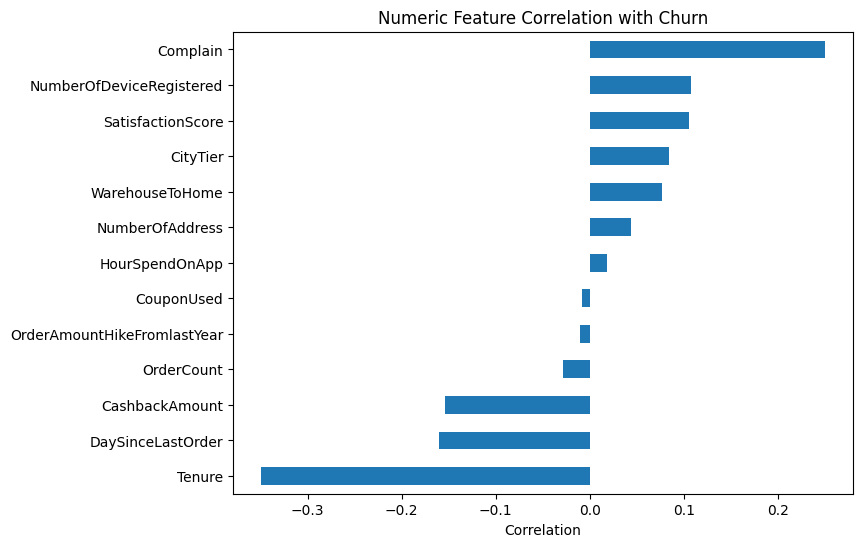

In [33]:
plt.figure(figsize=(8,6))
corr.drop(TARGET).sort_values().plot(kind='barh')
plt.title('Numeric Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.show()

## 13. Simple Feature Engineering


In [34]:
df_fe = df.copy()

# Safe feature engineering: only create if columns exist.
if 'OrderCount' in df_fe.columns and 'Tenure' in df_fe.columns:
    df_fe['Orders_Per_Month'] = df_fe['OrderCount'] / (df_fe['Tenure'] + 1)

if 'CashbackAmount' in df_fe.columns and 'OrderCount' in df_fe.columns:
    df_fe['Cashback_Per_Order'] = df_fe['CashbackAmount'] / (df_fe['OrderCount'] + 1)

if 'DaySinceLastOrder' in df_fe.columns and 'OrderCount' in df_fe.columns:
    df_fe['Recency_Order_Ratio'] = df_fe['DaySinceLastOrder'] / (df_fe['OrderCount'] + 1)

print('New shape:', df_fe.shape)
df_fe.head()

New shape: (5630, 23)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Orders_Per_Month,Cashback_Per_Order,Recency_Order_Ratio
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93,0.2,79.965,2.5
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90,NaN,60.450,0.0
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28,NaN,60.140,1.5
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07,1.0,67.035,1.5
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,1.0,64.800,1.5


## 14. Prepare Train/Test Data

We split data so the model is tested on customers it has not seen before.

In [35]:
id_like_cols = [col for col in df_fe.columns if col.lower() in ['customerid', 'customer_id', 'id']]
X = df_fe.drop(columns=[TARGET] + id_like_cols, errors='ignore')
y = df_fe[TARGET]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train churn rate:', y_train.mean())
print('Test churn rate:', y_test.mean())

Train shape: (4504, 21)
Test shape: (1126, 21)
Train churn rate: 0.16829484902309058
Test churn rate: 0.16873889875666073


## 15. Preprocessing Pipeline

- Numeric columns: fill missing values with median and scale
- Categorical columns: fill missing values with most frequent value and one-hot encode

In [36]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 16. Helper Function for Model Evaluation

In [38]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    print(model_name)
    print('-' * len(model_name))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    print('ROC-AUC:', metrics['roc_auc'])

    return metrics, y_proba

## 17. Model 1: Logistic Regression

In [39]:
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

log_reg_model.fit(X_train, y_train)
log_metrics, log_proba = evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

Logistic Regression
-------------------
Confusion Matrix:
[[752 184]
 [ 30 160]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.88       936
           1       0.47      0.84      0.60       190

    accuracy                           0.81      1126
   macro avg       0.71      0.82      0.74      1126
weighted avg       0.88      0.81      0.83      1126

ROC-AUC: 0.8909525416104364


## 18. Model 2: Random Forest

Stronger than Logistic Regression and gives useful feature importance.

In [40]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_metrics, rf_proba = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

Random Forest
-------------
Confusion Matrix:
[[923  13]
 [ 24 166]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.93      0.87      0.90       190

    accuracy                           0.97      1126
   macro avg       0.95      0.93      0.94      1126
weighted avg       0.97      0.97      0.97      1126

ROC-AUC: 0.9960526315789473


## 19. Model 3: XGBoost

In [41]:
model_results = [log_metrics, rf_metrics]
proba_dict = {
    'Logistic Regression': log_proba,
    'Random Forest': rf_proba
}

try:
    from xgboost import XGBClassifier

    xgb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ])

    xgb_model.fit(X_train, y_train)
    xgb_metrics, xgb_proba = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
    model_results.append(xgb_metrics)
    proba_dict['XGBoost'] = xgb_proba
except Exception as e:
    print('Skipping XGBoost. Reason:', e)

XGBoost
-------
Confusion Matrix:
[[920  16]
 [ 39 151]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       936
           1       0.90      0.79      0.85       190

    accuracy                           0.95      1126
   macro avg       0.93      0.89      0.91      1126
weighted avg       0.95      0.95      0.95      1126

ROC-AUC: 0.9791273054430949


## 20. Compare Models

For churn, **recall** is very important because we want to catch customers likely to leave.

But if precision is too low, we waste coupons on customers who would not churn.

In [42]:
results_df = pd.DataFrame(model_results).sort_values('roc_auc', ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.967140,0.927374,0.873684,0.899729,0.996053
2,XGBoost,0.951155,0.904192,0.794737,0.845938,0.979127
0,Logistic Regression,0.809947,0.465116,0.842105,0.599251,0.890953


## 21. ROC Curve

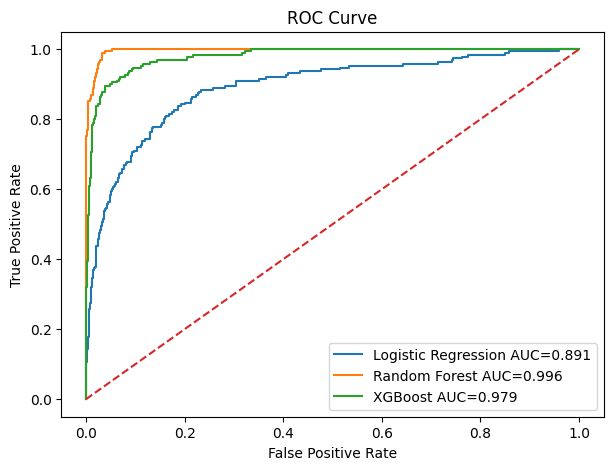

In [43]:
plt.figure(figsize=(7,5))
for model_name, probs in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} AUC={auc:.3f}')

plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 22. Precision-Recall Tradeoff

In business terms:

- Higher recall = catch more churners
- Higher precision = waste fewer offers

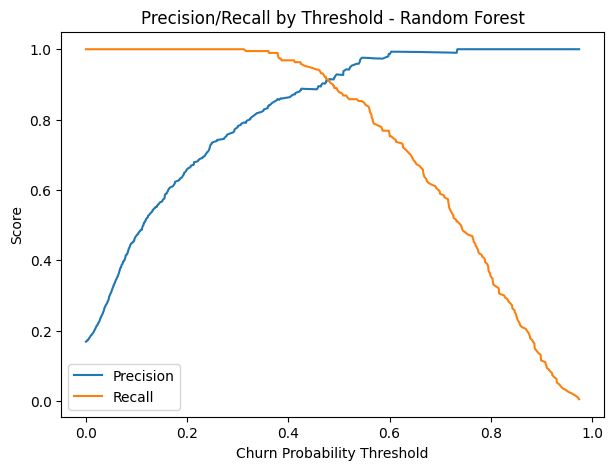

In [44]:
best_model_name = results_df.iloc[0]['model']
best_probs = proba_dict[best_model_name]

precision, recall, thresholds = precision_recall_curve(y_test, best_probs)

plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.title(f'Precision/Recall by Threshold - {best_model_name}')
plt.xlabel('Churn Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

## 23. Choose Business Threshold

Change `BUSINESS_THRESHOLD` and observe how precision/recall changes.

In [46]:
BUSINESS_THRESHOLD = 0.40

business_pred = (best_probs >= BUSINESS_THRESHOLD).astype(int)

print('Best model:', best_model_name)
print('Threshold:', BUSINESS_THRESHOLD)
print('Confusion Matrix:')
print(confusion_matrix(y_test, business_pred))
print('Classification Report:')
print(classification_report(y_test, business_pred))

Best model: Random Forest
Threshold: 0.4
Confusion Matrix:
[[907  29]
 [  6 184]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       936
           1       0.86      0.97      0.91       190

    accuracy                           0.97      1126
   macro avg       0.93      0.97      0.95      1126
weighted avg       0.97      0.97      0.97      1126



## 24. Feature Importance — Random Forest

This tells us which variables helped the model most.

Note: Feature importance is not perfect causality, but it is useful for storytelling.

,feature,importance
0,Tenure,0.188807
13,Orders_Per_Month,0.147924
12,CashbackAmount,0.074761
14,Cashback_Per_Order,0.057608
7,Complain,0.056909
15,Recency_Order_Ratio,0.047399
2,WarehouseToHome,0.044933
6,NumberOfAddress,0.041646
11,DaySinceLastOrder,0.036061
5,SatisfactionScore,0.035853


<Figure size 800x600 with 0 Axes>

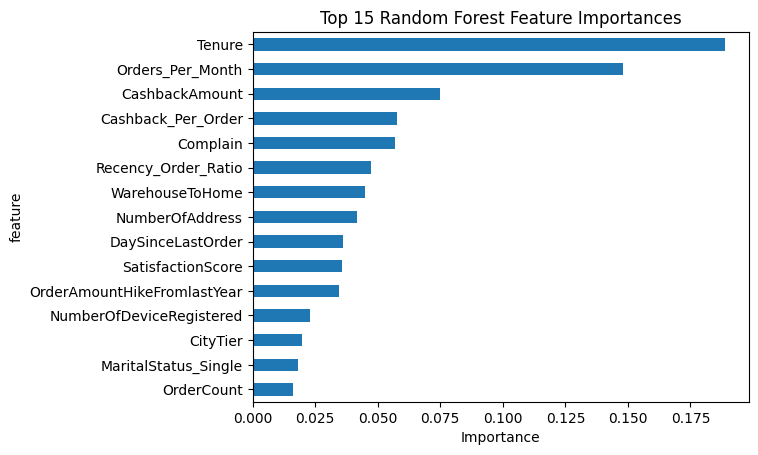

In [47]:
def get_feature_names(preprocessor):
    output_features = []

    if len(numeric_features) > 0:
        output_features.extend(numeric_features)

    if len(categorical_features) > 0:
        cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
        output_features.extend(cat_features)

    return output_features

try:
    fitted_preprocessor = rf_model.named_steps['preprocessor']
    feature_names = get_feature_names(fitted_preprocessor)
    importances = rf_model.named_steps['classifier'].feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8,6))
    importance_df.head(15).sort_values('importance').plot(x='feature', y='importance', kind='barh', legend=False)
    plt.title('Top 15 Random Forest Feature Importances')
    plt.xlabel('Importance')
    plt.show()
except Exception as e:
    print('Could not compute feature importance:', e)

## 25. Create Customer Churn Risk Table

This is the business output.

Product teams can use it to decide who should receive a retention offer.

In [51]:
risk_table = X_test.copy()
risk_table['actual_churn'] = y_test.values
risk_table['predicted_churn_probability'] = best_probs
risk_table['risk_segment'] = pd.cut(
    risk_table['predicted_churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_table.sort_values('predicted_churn_probability', ascending=False).head(20)

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Orders_Per_Month,Cashback_Per_Order,Recency_Order_Ratio,actual_churn,predicted_churn_probability,risk_segment
4617,1.0,Computer,3,12.0,E wallet,Male,4.0,4,Mobile Phone,4,Single,3,1,15.0,2.0,2.0,1.0,143.78,1.0,47.926667,0.333333,1,0.974400,High Risk
4287,1.0,Phone,3,29.0,E wallet,Male,3.0,4,Mobile Phone,3,Single,3,1,20.0,2.0,2.0,1.0,141.75,1.0,47.250000,0.333333,1,0.971843,High Risk
1011,0.0,Phone,1,NaN,CC,Male,2.0,3,Mobile,4,Married,2,1,17.0,0.0,1.0,0.0,124.08,1.0,62.040000,0.000000,1,0.966943,High Risk
5433,1.0,Phone,1,15.0,Credit Card,Female,4.0,4,Mobile Phone,5,Married,3,1,18.0,1.0,2.0,1.0,148.98,1.0,49.660000,0.333333,1,0.960870,High Risk
3750,1.0,Computer,1,16.0,Credit Card,Male,3.0,4,Mobile Phone,5,Single,4,1,12.0,1.0,2.0,1.0,156.72,1.0,52.240000,0.333333,1,0.952913,High Risk
338,0.0,Phone,1,NaN,COD,Male,3.0,5,Mobile,2,Single,2,1,18.0,1.0,1.0,0.0,123.40,1.0,61.700000,0.000000,1,0.948070,High Risk
4022,1.0,Computer,1,31.0,Debit Card,Male,4.0,5,Mobile Phone,1,Single,3,1,25.0,2.0,2.0,1.0,149.39,1.0,49.796667,0.333333,1,0.941399,High Risk
932,0.0,Computer,3,19.0,COD,Female,2.0,3,Laptop & Accessory,4,Single,6,0,11.0,0.0,1.0,0.0,157.65,1.0,78.825000,0.000000,1,0.938147,High Risk
1802,NaN,Computer,3,11.0,E wallet,Male,3.0,3,Mobile Phone,4,Single,2,1,14.0,1.0,1.0,0.0,118.78,NaN,59.390000,0.000000,1,0.935310,High Risk
4869,1.0,Computer,1,16.0,Credit Card,Male,3.0,5,Mobile Phone,5,Single,2,1,23.0,1.0,2.0,3.0,148.21,1.0,49.403333,1.000000,1,0.930445,High Risk


## 26. Risk Segment Summary

In [52]:
risk_summary = risk_table.groupby('risk_segment').agg(
    customers=('predicted_churn_probability', 'count'),
    avg_predicted_churn_probability=('predicted_churn_probability', 'mean'),
    actual_churn_rate=('actual_churn', 'mean')
).reset_index()

risk_summary

,risk_segment,customers,avg_predicted_churn_probability,actual_churn_rate
0,Low Risk,871,0.062159,0.000000
1,Medium Risk,98,0.457289,0.479592
2,High Risk,145,0.788469,0.986207


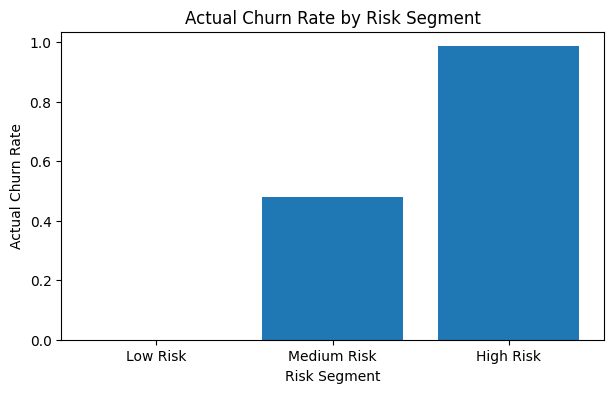

In [53]:
plt.figure(figsize=(7,4))
plt.bar(risk_summary['risk_segment'].astype(str), risk_summary['actual_churn_rate'])
plt.title('Actual Churn Rate by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Actual Churn Rate')
plt.show()

## 27. Simple Retention Campaign Simulation

Imagine we send coupons only to high-risk users.

Assumptions:

- Coupon cost: $10 per customer
- Average retained customer value: $80
- Campaign saves 15% of customers who would have churned

In [54]:
COUPON_COST = 10
CUSTOMER_VALUE = 80
SAVE_RATE = 0.15

high_risk = risk_table[risk_table['risk_segment'] == 'High Risk'].copy()

num_targeted = len(high_risk)
expected_churners = high_risk['actual_churn'].sum()
expected_saved = expected_churners * SAVE_RATE
revenue_saved = expected_saved * CUSTOMER_VALUE
campaign_cost = num_targeted * COUPON_COST
net_impact = revenue_saved - campaign_cost

campaign_summary = pd.DataFrame({
    'metric': [
        'Customers targeted',
        'Expected churners in targeted group',
        'Expected customers saved',
        'Revenue saved',
        'Campaign cost',
        'Net impact'
    ],
    'value': [
        num_targeted,
        expected_churners,
        expected_saved,
        revenue_saved,
        campaign_cost,
        net_impact
    ]
})

campaign_summary

,metric,value
0,Customers targeted,145.00
1,Expected churners in targeted group,143.00
2,Expected customers saved,21.45
3,Revenue saved,1716.00
4,Campaign cost,1450.00
5,Net impact,266.00


## 28. Save Outputs

Save predictions and model comparison results.

In [55]:
risk_table.to_csv('customer_churn_risk_scores.csv', index=False)
results_df.to_csv('model_comparison_results.csv', index=False)

print('Saved: customer_churn_risk_scores.csv')
print('Saved: model_comparison_results.csv')

Saved: customer_churn_risk_scores.csv
Saved: model_comparison_results.csv
